In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
open_mesh_path = "/content/drive/MyDrive/DataSets/MSResearch/openMesh/"

## Merge Open Mesh Sidelink Data (metaData + rawData) + Weather data for 2023-Oct till 2025-May

In [4]:
open_mesh_path = "/content/drive/MyDrive/DataSets/MSResearch/openMesh/"
merged_link_df = pd.read_csv(open_mesh_path+"merged_link_df.csv")

/tmp/ipython-input-1033733568.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_link_df = pd.read_csv(open_mesh_path+"merged_link_df.csv")


In [5]:
temp_directory_path = '/content/drive/MyDrive/DataSets/MSResearch/30Sep/'
weather_2023_2024_df = pd.read_csv(temp_directory_path+"weather_2023_2024_df.csv")

In [6]:
merged_link_df.shape, weather_2023_2024_df.shape

((25760346, 10), (101609, 4))

## Weather Data Analysis

In [7]:
weather_2023_2024_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101609 entries, 0 to 101608
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Temperature_C   101609 non-null  float64
 1   Wind_Speed_kmh  101569 non-null  float64
 2   Humidity_pct    101609 non-null  float64
 3   Date_Time       101609 non-null  object 
dtypes: float64(3), object(1)
memory usage: 3.1+ MB


In [8]:
weather_2023_2024_df['Date_Time'].isna().sum()

np.int64(0)

In [9]:
weather_2023_2024_df['Date_Time'] = pd.to_datetime(weather_2023_2024_df['Date_Time'])

In [10]:
weather_2023_2024_df.sort_values(by='Date_Time', inplace=True)

In [11]:
weather_2023_2024_df.shape

(101609, 4)

In [12]:
# Extract year and month from 'Datetime' and count occurrences
weather_2023_2024_df['year_month'] = weather_2023_2024_df['Date_Time'].dt.to_period('M')
year_month_counts = weather_2023_2024_df['year_month'].value_counts().sort_index()

# Display the counts
display(year_month_counts)

,count
year_month,
2023-09,843
2023-10,794
2024-01,22156
2024-02,20927
2024-03,22404
2024-04,21636
2024-05,12849


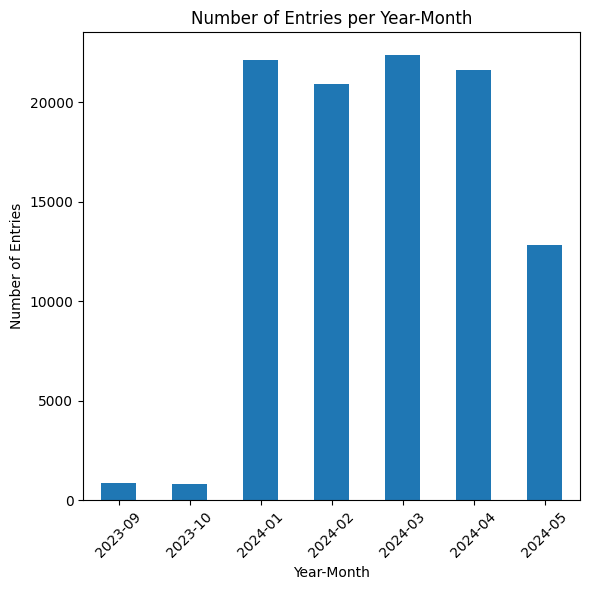

In [13]:
plt.figure(figsize=(6, 6))
year_month_counts.plot(kind='bar')
plt.title('Number of Entries per Year-Month')
plt.xlabel('Year-Month')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

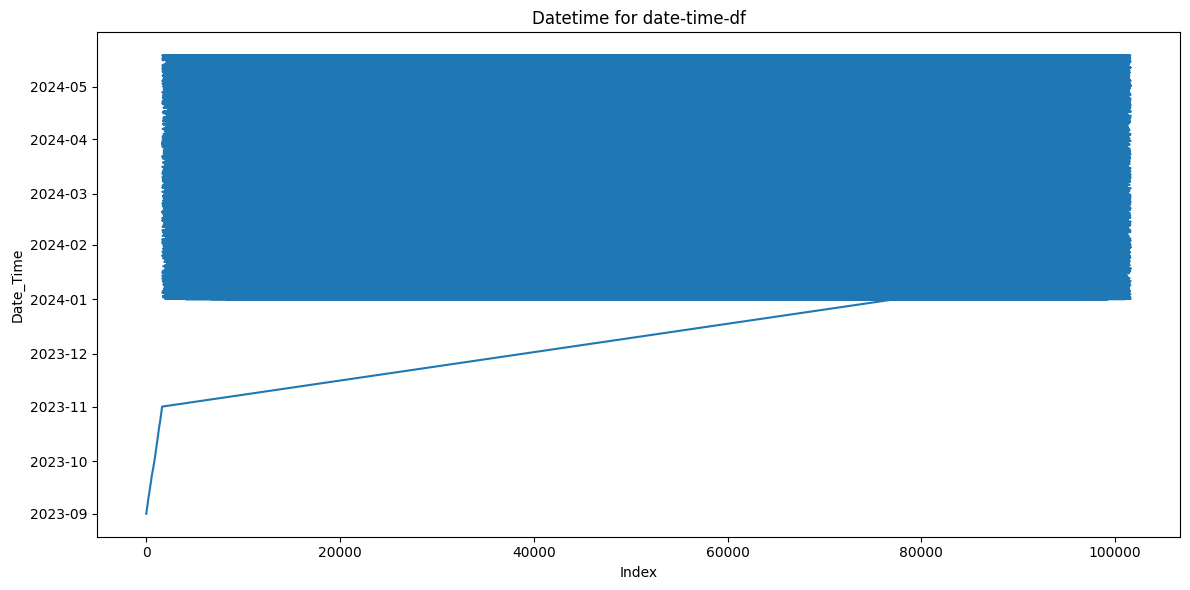

In [14]:
# Filter for sublink_id = 1
date_time_df = weather_2023_2024_df['Date_Time'].copy()
date_time_df = pd.to_datetime(date_time_df)

# Plot the Datetime column
plt.figure(figsize=(12, 6))
plt.plot(date_time_df)
plt.title('Datetime for date-time-df')
plt.xlabel('Index')
plt.ylabel('Date_Time')
plt.tight_layout()
plt.show()

In [18]:
weather_2023_2024_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101609 entries, 0 to 34196
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Temperature_C   101609 non-null  float64       
 1   Wind_Speed_kmh  101569 non-null  float64       
 2   Humidity_pct    101609 non-null  float64       
 3   Date_Time       101609 non-null  datetime64[ns]
 4   year_month      101609 non-null  period[M]     
dtypes: datetime64[ns](1), float64(3), period[M](1)
memory usage: 4.7 MB


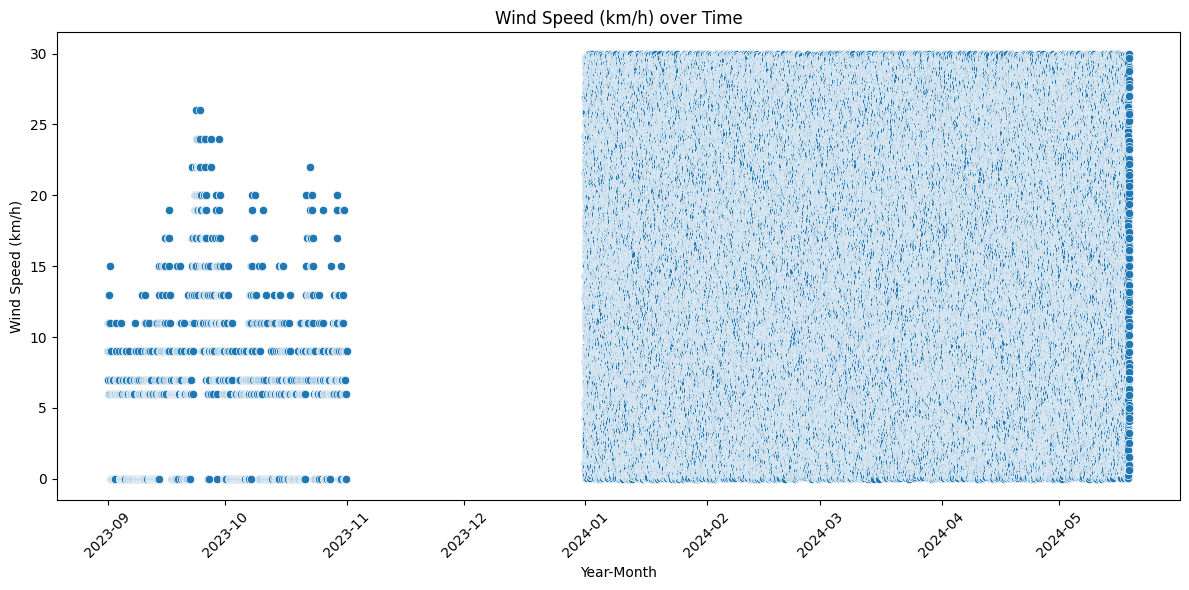

In [20]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=weather_2023_2024_df, x=weather_2023_2024_df['Date_Time'], y='Wind_Speed_kmh')
plt.title('Wind Speed (km/h) over Time')
plt.xlabel('Year-Month')
plt.ylabel('Wind Speed (km/h)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

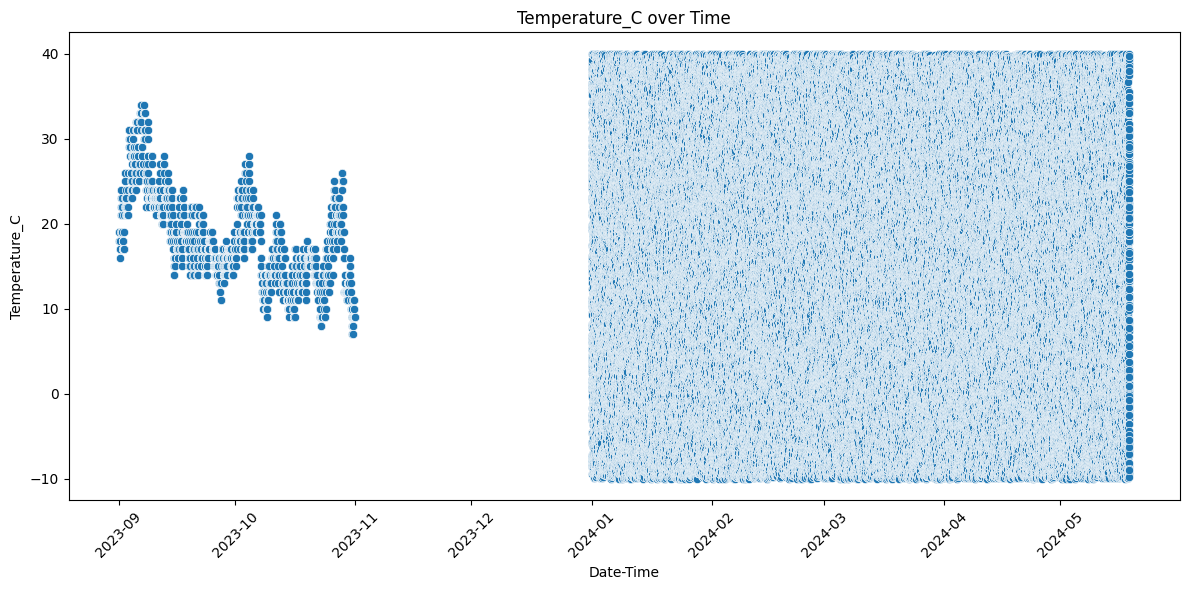

In [22]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=weather_2023_2024_df, x=weather_2023_2024_df['Date_Time'], y='Temperature_C')
plt.title('Temperature_C over Time')
plt.xlabel('Date-Time')
plt.ylabel('Temperature_C')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

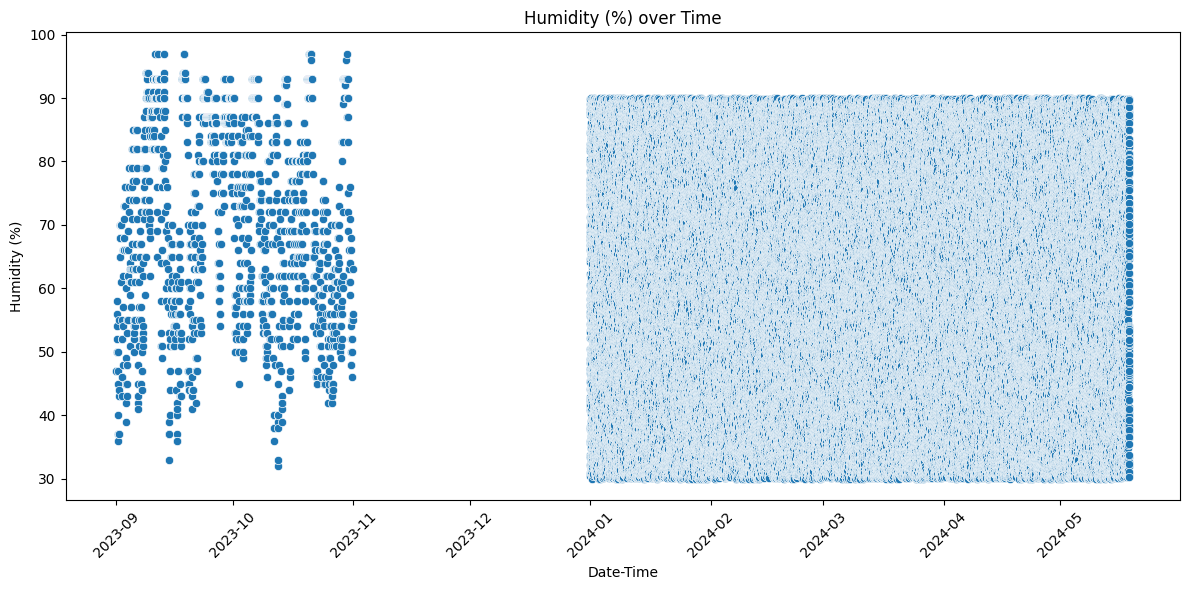

In [23]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=weather_2023_2024_df, x=weather_2023_2024_df['Date_Time'], y='Humidity_pct')
plt.title('Humidity (%) over Time')
plt.xlabel('Date-Time')
plt.ylabel('Humidity (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Merge Weather Data with Link data on date-time column


In [ ]:
# Convert 'Datetime' columns to datetime objects if not already done
merged_link_df['Datetime'] = pd.to_datetime(merged_link_df['Datetime'])
weather_2023_2024_df['Datetime'] = pd.to_datetime(weather_2023_2024_df['Datetime'])

# Merge the dataframes on the 'Datetime' column to find common entries
common_datetimes_df = pd.merge(merged_link_df, weather_2023_2024_df, on='Datetime', how='inner')

# Count the number of common datetime entries
count_common_datetimes = common_datetimes_df.shape[0]

# Print the count
print(f"Number of common datetime entries: {count_common_datetimes}")

Number of common datetime entries: 154592


In [ ]:
merged_link_df.tail()

,Datetime,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl
25760341,2024-05-12 08:05:00,103,-69.0,5710,1834.8,40.815434,-73.950275,40.830386,-73.941022,-69.0
25760342,2024-05-12 08:06:00,103,-69.0,5710,1834.8,40.815434,-73.950275,40.830386,-73.941022,-69.0
25760343,2024-05-12 08:07:00,103,-68.0,5710,1834.8,40.815434,-73.950275,40.830386,-73.941022,-69.0
25760344,2024-05-12 08:08:00,103,-69.0,5710,1834.8,40.815434,-73.950275,40.830386,-73.941022,-69.0
25760345,2024-05-12 08:09:00,103,-68.0,5710,1834.8,40.815434,-73.950275,40.830386,-73.941022,-69.0


In [ ]:
# Rename the date column in weather_2023_2024_df
weather_2023_2024_df = weather_2023_2024_df.rename(columns={'Date_Time': 'Datetime'})

# Convert the 'Datetime' column to datetime objects in both dataframes
merged_link_df['Datetime'] = pd.to_datetime(merged_link_df['Datetime'])
weather_2023_2024_df['Datetime'] = pd.to_datetime(weather_2023_2024_df['Datetime'])

# Merge the dataframes on the 'Datetime' column
merged_df = pd.merge(merged_link_df, weather_2023_2024_df, on='Datetime', how='inner')

display(merged_df.head())

,Datetime,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl,Temperature_C,Wind_Speed_kmh,Humidity_pct
0,2023-10-29 00:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0,17.0,7.0,56.0
1,2023-10-29 01:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0,17.0,7.0,56.0
2,2023-10-29 02:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0,16.0,11.0,58.0
3,2023-10-29 03:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0,16.0,9.0,52.0
4,2023-10-29 04:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0,12.0,6.0,83.0


In [ ]:
display(merged_df.describe())

,Datetime,sublink_id,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl,Temperature_C,Wind_Speed_kmh,Humidity_pct
count,154592,154592.000000,154592.000000,154592.000000,154592.000000,154592.000000,154592.000000,154592.000000,154592.000000,154592.000000,154493.000000,154592.000000
mean,2024-03-04 07:26:05.656825344,51.866300,30390.199978,1638.204340,40.697955,-73.966099,40.700323,-73.961283,-59.906431,14.403585,15.100591,60.788351
min,2023-10-29 00:51:00,1.000000,5270.000000,24.500000,40.606661,-74.013631,40.601913,-74.013680,-83.000000,-9.991065,0.000000,30.122458
25%,2024-01-29 22:29:00,26.000000,5560.000000,582.300000,40.672601,-73.990370,40.674444,-73.983635,-64.000000,2.438279,7.681392,46.556329
50%,2024-03-02 22:05:00,52.000000,5810.000000,1397.800000,40.696033,-73.964204,40.696002,-73.954799,-59.000000,13.660476,14.966575,61.138207
75%,2024-04-10 09:41:00,78.000000,64800.000000,2220.000000,40.719898,-73.941022,40.724676,-73.941022,-56.000000,26.002169,22.863123,74.890636
max,2024-05-12 06:25:00,103.000000,69120.000000,6936.500000,40.830386,-73.913606,40.830386,-73.906361,-34.000000,39.980993,29.994572,97.000000
std,NaN,29.781584,28104.137663,1334.316028,0.038961,0.029657,0.039611,0.028365,7.332617,14.027990,8.691299,17.081765


In [ ]:
# Specify the date you want to count
date_to_count = '2023-10-29'

# Convert 'Datetime' to datetime objects if not already done
merged_df['Datetime'] = pd.to_datetime(merged_df['Datetime'])

# Filter the DataFrame for rows matching the specified date and count them
count_for_date = merged_df[merged_df['Datetime'].dt.date == pd.to_datetime(date_to_count).date()].shape[0]

# Print the count
print(f"Number of entries for {date_to_count}: {count_for_date}")

Number of entries for 2023-10-29: 1608


In [ ]:
merged_df.shape

(154592, 13)

In [ ]:
merged_df.to_csv(open_mesh_path+"merged_df.csv", index=False)

## Checkpoint1: Load Merged_df (Weather Data + Data Link combined) 154592 rows with 13 columns

In [ ]:
open_mesh_path = "/content/drive/MyDrive/DataSets/MSResearch/openMesh/"
merged_df = pd.read_csv(open_mesh_path+"merged_df.csv")

In [ ]:
merged_df.head()

,Datetime,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl,Temperature_C,Wind_Speed_kmh,Humidity_pct
0,2023-10-29 00:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0,17.0,7.0,56.0
1,2023-10-29 01:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0,17.0,7.0,56.0
2,2023-10-29 02:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0,16.0,11.0,58.0
3,2023-10-29 03:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0,16.0,9.0,52.0
4,2023-10-29 04:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,40.73391,-73.950594,-60.0,12.0,6.0,83.0


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154592 entries, 0 to 154591
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Datetime        154592 non-null  object 
 1   sublink_id      154592 non-null  int64  
 2   rsl_value       154592 non-null  float64
 3   frequency       154592 non-null  int64  
 4   length          154592 non-null  float64
 5   site_0_lat      154592 non-null  float64
 6   site_0_lon      154592 non-null  float64
 7   site_1_lat      154592 non-null  float64
 8   site_1_lon      154592 non-null  float64
 9   rsl             154592 non-null  float64
 10  Temperature_C   154592 non-null  float64
 11  Wind_Speed_kmh  154493 non-null  float64
 12  Humidity_pct    154592 non-null  float64
dtypes: float64(10), int64(2), object(1)
memory usage: 15.3+ MB


In [ ]:
merged_df[merged_df['Wind_Speed_kmh'].isna()].head()

,Datetime,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl,Temperature_C,Wind_Speed_kmh,Humidity_pct
44,2023-10-30 08:51:00,1,-68.0,62640,623.0,40.729552,-73.945949,40.733910,-73.950594,-60.0,13.0,NaN,93.0
58,2023-10-30 20:51:00,1,-66.0,62640,623.0,40.729552,-73.945949,40.733910,-73.950594,-60.0,12.0,NaN,66.0
1597,2023-10-30 08:51:00,2,-63.0,60480,222.1,40.727553,-73.946045,40.729552,-73.945949,-62.0,13.0,NaN,93.0
1611,2023-10-30 20:51:00,2,-61.0,60480,222.1,40.727553,-73.946045,40.729552,-73.945949,-62.0,12.0,NaN,66.0
3175,2023-10-30 08:51:00,3,-62.0,62640,623.0,40.729552,-73.945949,40.733910,-73.950594,-60.0,13.0,NaN,93.0


In [ ]:
merged_df.describe()

,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl,Temperature_C,Wind_Speed_kmh,Humidity_pct
count,154592.000000,154592.000000,154592.000000,154592.000000,154592.000000,154592.000000,154592.000000,154592.000000,154592.000000,154592.000000,154493.000000,154592.000000
mean,51.866300,-59.889716,30390.199978,1638.204340,40.697955,-73.966099,40.700323,-73.961283,-59.906431,14.403585,15.100591,60.788351
std,29.781584,7.661037,28104.137663,1334.316028,0.038961,0.029657,0.039611,0.028365,7.332617,14.027990,8.691299,17.081765
min,1.000000,-86.000000,5270.000000,24.500000,40.606661,-74.013631,40.601913,-74.013680,-83.000000,-9.991065,0.000000,30.122458
25%,26.000000,-65.000000,5560.000000,582.300000,40.672601,-73.990370,40.674444,-73.983635,-64.000000,2.438279,7.681392,46.556329
50%,52.000000,-59.000000,5810.000000,1397.800000,40.696033,-73.964204,40.696002,-73.954799,-59.000000,13.660476,14.966575,61.138207
75%,78.000000,-55.000000,64800.000000,2220.000000,40.719898,-73.941022,40.724676,-73.941022,-56.000000,26.002169,22.863123,74.890636
max,103.000000,-29.000000,69120.000000,6936.500000,40.830386,-73.913606,40.830386,-73.906361,-34.000000,39.980993,29.994572,97.000000


In [ ]:
merged_df = merged_df[~merged_df['Wind_Speed_kmh'].isna()]

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154493 entries, 0 to 154591
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Datetime        154493 non-null  object 
 1   sublink_id      154493 non-null  int64  
 2   rsl_value       154493 non-null  float64
 3   frequency       154493 non-null  int64  
 4   length          154493 non-null  float64
 5   site_0_lat      154493 non-null  float64
 6   site_0_lon      154493 non-null  float64
 7   site_1_lat      154493 non-null  float64
 8   site_1_lon      154493 non-null  float64
 9   rsl             154493 non-null  float64
 10  Temperature_C   154493 non-null  float64
 11  Wind_Speed_kmh  154493 non-null  float64
 12  Humidity_pct    154493 non-null  float64
dtypes: float64(10), int64(2), object(1)
memory usage: 16.5+ MB


In [ ]:
merged_df['Datetime'] = pd.to_datetime(merged_df['Datetime'])

In [ ]:
merged_df.describe()

,Datetime,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl,Temperature_C,Wind_Speed_kmh,Humidity_pct
count,154493,154493.000000,154493.000000,154493.000000,154493.000000,154493.000000,154493.000000,154493.000000,154493.000000,154493.000000,154493.000000,154493.000000,154493.000000
mean,2024-03-04 09:22:04.478649344,51.879554,-59.890662,30374.820574,1638.096184,40.697952,-73.966100,40.700319,-73.961284,-59.908086,14.404808,15.100591,60.776447
min,2023-10-29 00:51:00,1.000000,-86.000000,5270.000000,24.500000,40.606661,-74.013631,40.601913,-74.013680,-83.000000,-9.991065,0.000000,30.122458
25%,2024-01-29 22:29:00,27.000000,-65.000000,5560.000000,582.300000,40.672601,-73.990370,40.674444,-73.983635,-64.000000,2.438279,7.681392,46.556329
50%,2024-03-02 22:12:00,52.000000,-59.000000,5810.000000,1397.800000,40.696033,-73.964204,40.696002,-73.954799,-59.000000,13.664718,14.966575,61.131892
75%,2024-04-10 09:41:00,78.000000,-55.000000,64800.000000,2220.000000,40.719898,-73.941022,40.724676,-73.941022,-56.000000,26.002169,22.863123,74.890636
max,2024-05-12 06:25:00,103.000000,-29.000000,69120.000000,6936.500000,40.830386,-73.913606,40.830386,-73.906361,-34.000000,39.980993,29.994572,97.000000
std,NaN,29.782790,7.661912,28102.235378,1334.254747,0.038960,0.029659,0.039610,0.028366,7.333852,14.032395,8.691299,17.077343


In [ ]:
merged_df['frequency'].value_counts()

,count
frequency,
68040,20343
5560,12001
5490,11764
5710,10478
64800,10426
58320,8544
60480,7347
24200,6424
24100,6384


In [ ]:
merged_df.corr()

,Datetime,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,site_1_lat,site_1_lon,rsl,Temperature_C,Wind_Speed_kmh,Humidity_pct
Datetime,1.000000,0.061097,-0.039861,-0.082453,-0.016345,-0.026874,-0.013335,-0.027135,-0.016599,-0.032084,0.050446,0.062436,-0.090136
sublink_id,0.061097,1.000000,-0.275148,-0.592642,-0.052206,-0.077535,-0.153193,-0.144324,-0.187237,-0.384216,0.004343,0.014747,-0.018158
rsl_value,-0.039861,-0.275148,1.000000,0.236315,0.074406,0.059966,-0.051714,0.092961,-0.080979,0.718635,-0.003492,-0.002753,0.006757
frequency,-0.082453,-0.592642,0.236315,1.000000,0.049016,0.111553,0.196080,0.135706,0.212643,0.368783,-0.006113,-0.018277,0.021710
length,-0.016345,-0.052206,0.074406,0.049016,1.000000,-0.198833,-0.014747,-0.146534,0.125265,-0.019092,-0.001353,-0.003241,0.004236
site_0_lat,-0.026874,-0.077535,0.059966,0.111553,-0.198833,1.000000,0.271620,0.948122,0.221343,0.022957,-0.001359,-0.002007,0.003418
site_0_lon,-0.013335,-0.153193,-0.051714,0.196080,-0.014747,0.271620,1.000000,0.256601,0.813931,0.045755,-0.001668,-0.000487,0.000733
site_1_lat,-0.027135,-0.144324,0.092961,0.135706,-0.146534,0.948122,0.256601,1.000000,0.292577,0.084460,-0.001371,-0.002480,0.004121
site_1_lon,-0.016599,-0.187237,-0.080979,0.212643,0.125265,0.221343,0.813931,0.292577,1.000000,-0.006578,-0.001992,-0.001734,0.002965
rsl,-0.032084,-0.384216,0.718635,0.368783,-0.019092,0.022957,0.045755,0.084460,-0.006578,1.000000,-0.002720,-0.007127,0.008945


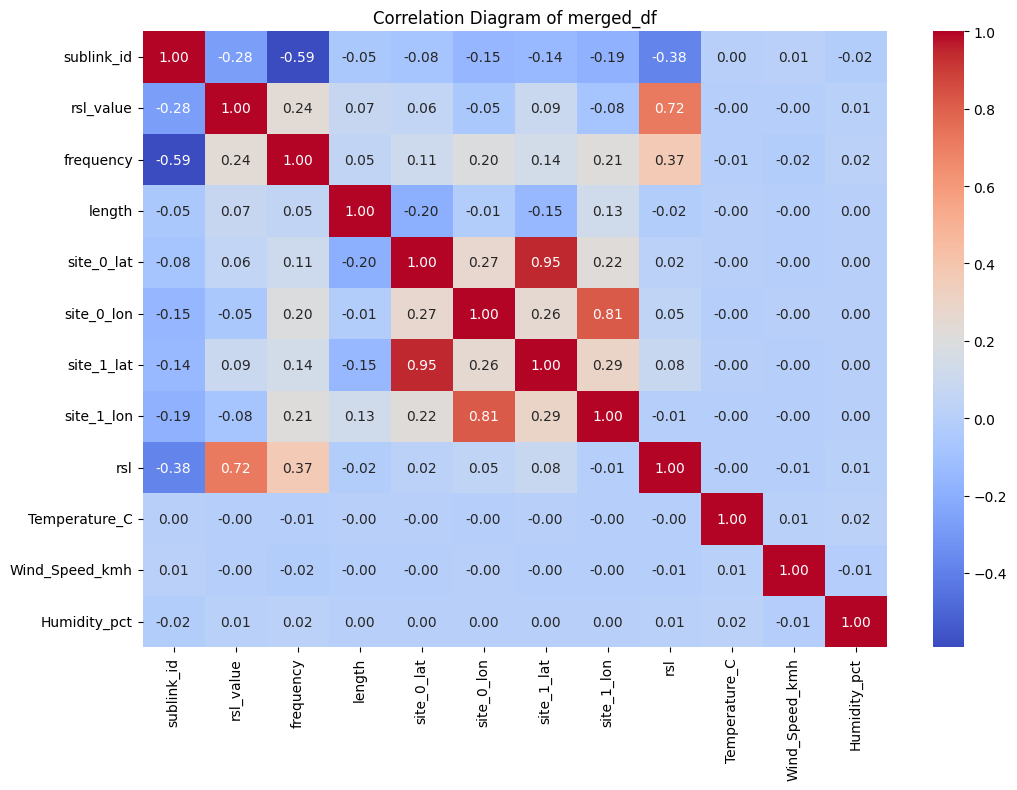

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = merged_df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Diagram of merged_df')
plt.show()

In [ ]:
#Drop columns with high correlation
merged_df.drop(columns=['site_1_lat', 'site_1_lon', 'rsl'], inplace=True)

In [ ]:
merged_df.shape

(154493, 10)

In [ ]:
merged_df.head()

,Datetime,sublink_id,rsl_value,frequency,length,site_0_lat,site_0_lon,Temperature_C,Wind_Speed_kmh,Humidity_pct
0,2023-10-29 00:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,17.0,7.0,56.0
1,2023-10-29 01:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,17.0,7.0,56.0
2,2023-10-29 02:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,16.0,11.0,58.0
3,2023-10-29 03:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,16.0,9.0,52.0
4,2023-10-29 04:51:00,1,-65.0,62640,623.0,40.729552,-73.945949,12.0,6.0,83.0


In [ ]:
# Extract year and month from 'Datetime' and count occurrences
merged_df['year_month'] = merged_df['Datetime'].dt.to_period('M')
year_month_counts = merged_df['year_month'].value_counts().sort_index()

# Display the counts
display(year_month_counts)

,count
year_month,
2023-10,4106
2024-01,36630
2024-02,33867
2024-03,30004
2024-04,35825
2024-05,14061


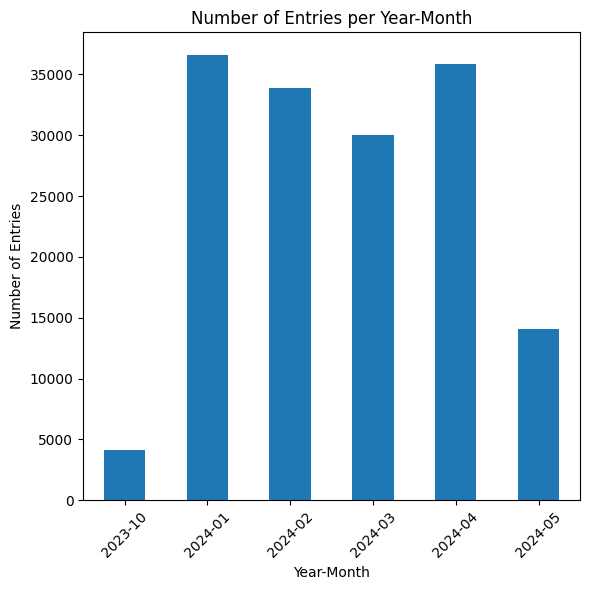

In [ ]:
plt.figure(figsize=(6, 6))
year_month_counts.plot(kind='bar')
plt.title('Number of Entries per Year-Month')
plt.xlabel('Year-Month')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

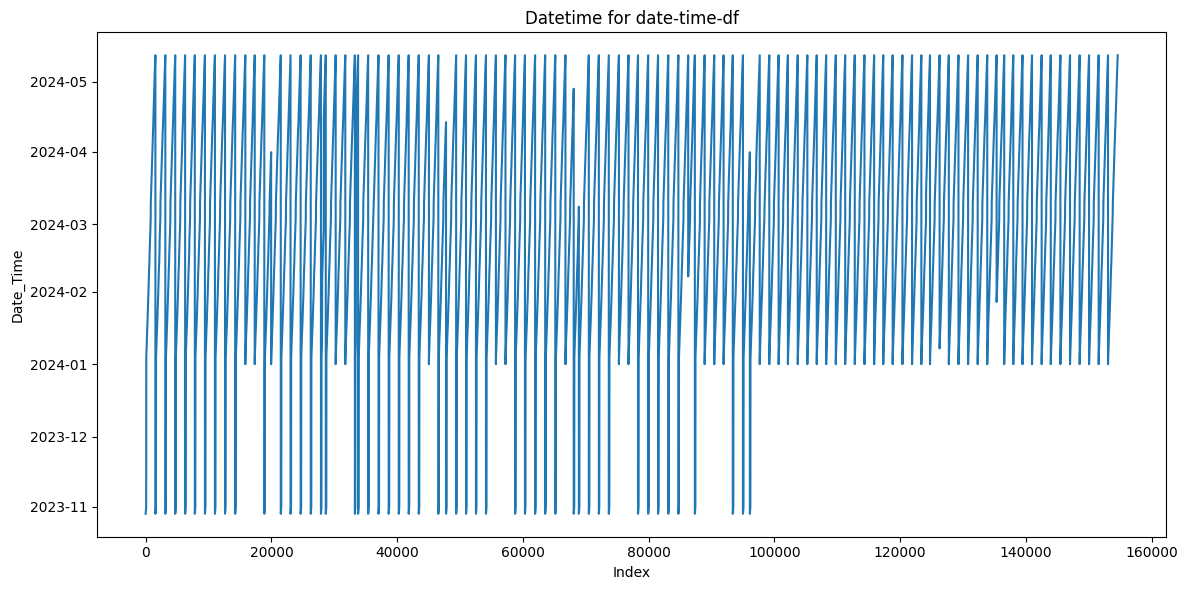

In [ ]:
# Filter for sublink_id = 1
date_time_df = merged_df['Datetime'].copy()
date_time_df = pd.to_datetime(date_time_df)

# Plot the Datetime column
plt.figure(figsize=(12, 6))
plt.plot(date_time_df)
plt.title('Datetime for date-time-df')
plt.xlabel('Index')
plt.ylabel('Date_Time')
plt.tight_layout()
plt.show()

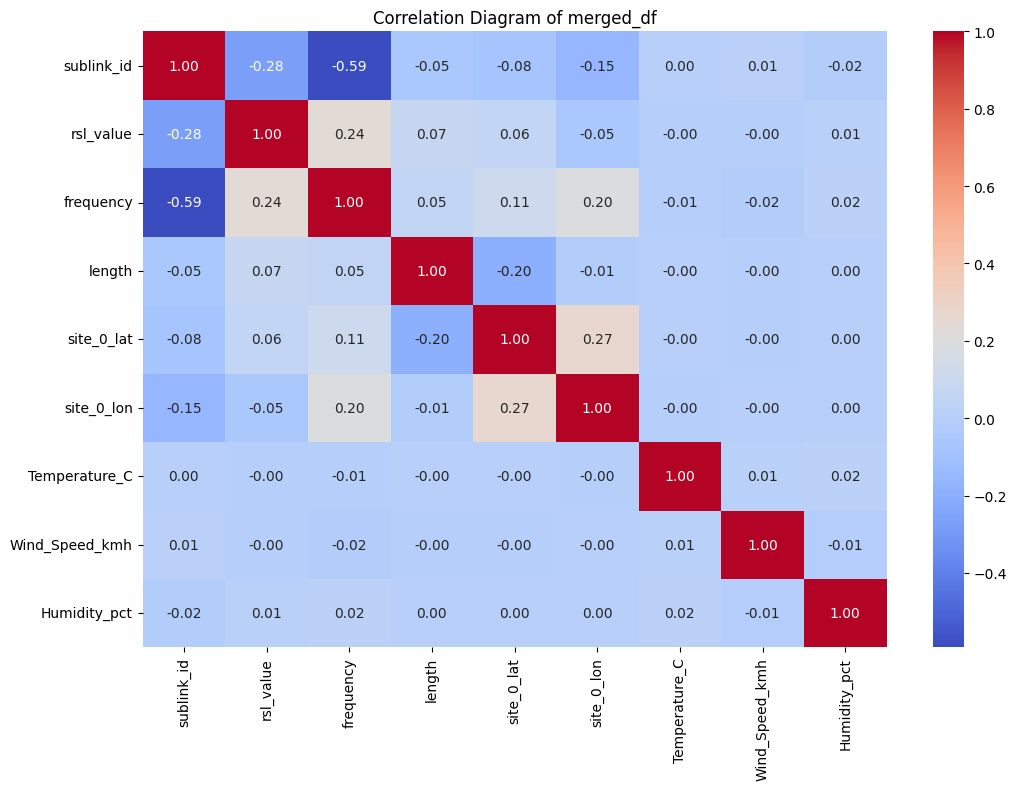

In [ ]:
# Calculate the correlation matrix
correlation_matrix = merged_df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Diagram of merged_df')
plt.show()

In [ ]:
merged_df.shape

(154493, 11)

In [ ]:
merged_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'site_0_lat', 'site_0_lon', 'Temperature_C', 'Wind_Speed_kmh',
       'Humidity_pct', 'year_month'],
      dtype='object')

In [ ]:
merged_df.drop(columns=['site_0_lat', 'site_0_lon'], inplace=True)

In [ ]:
merged_df.shape

(154493, 9)

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154493 entries, 0 to 154591
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Datetime        154493 non-null  datetime64[ns]
 1   sublink_id      154493 non-null  int64         
 2   rsl_value       154493 non-null  float64       
 3   frequency       154493 non-null  int64         
 4   length          154493 non-null  float64       
 5   Temperature_C   154493 non-null  float64       
 6   Wind_Speed_kmh  154493 non-null  float64       
 7   Humidity_pct    154493 non-null  float64       
 8   year_month      154493 non-null  period[M]     
dtypes: datetime64[ns](1), float64(5), int64(2), period[M](1)
memory usage: 11.8 MB


In [ ]:
merged_df.shape

(154493, 9)

In [ ]:
merged_df.head()

,Datetime,sublink_id,rsl_value,frequency,length,Temperature_C,Wind_Speed_kmh,Humidity_pct,year_month
0,2023-10-29 00:51:00,1,-65.0,62640,623.0,17.0,7.0,56.0,2023-10
1,2023-10-29 01:51:00,1,-65.0,62640,623.0,17.0,7.0,56.0,2023-10
2,2023-10-29 02:51:00,1,-65.0,62640,623.0,16.0,11.0,58.0,2023-10
3,2023-10-29 03:51:00,1,-65.0,62640,623.0,16.0,9.0,52.0,2023-10
4,2023-10-29 04:51:00,1,-65.0,62640,623.0,12.0,6.0,83.0,2023-10


In [ ]:
merged_df['sublink_id'].value_counts()

,count
sublink_id,
25,1642
55,1622
18,1618
10,1614
30,1614
...,...
13,1084
58,1056
46,816


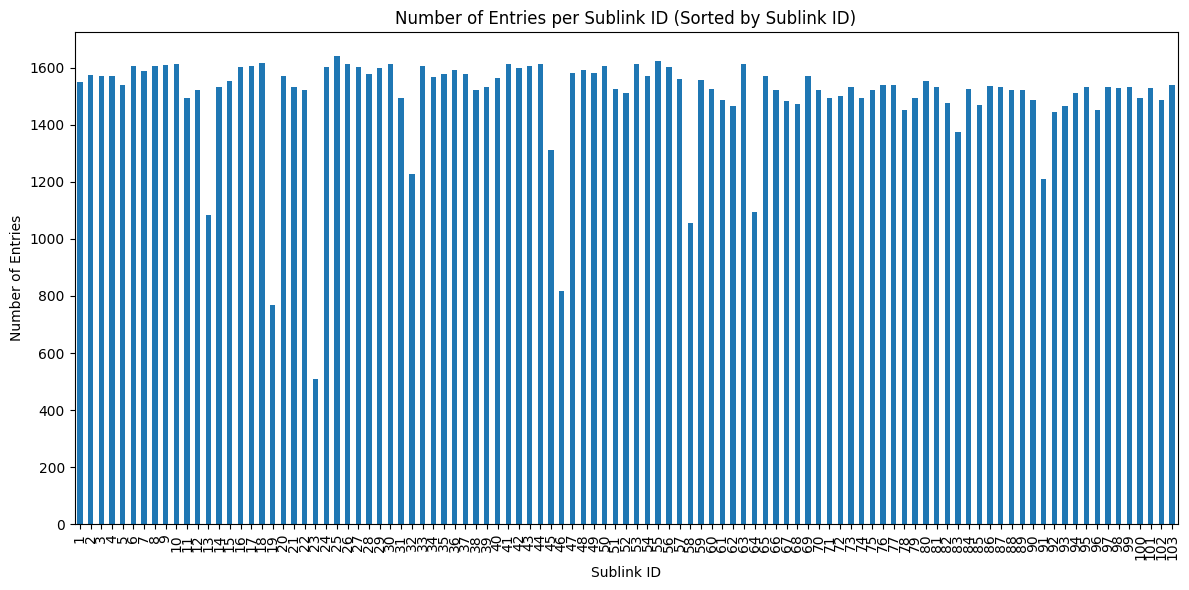

In [ ]:
merged_df['sublink_id'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6))
plt.title('Number of Entries per Sublink ID (Sorted by Sublink ID)')
plt.xlabel('Sublink ID')
plt.ylabel('Number of Entries')
plt.tight_layout()
plt.show()

In [ ]:
merged_df.head()

,Datetime,sublink_id,rsl_value,frequency,length,Temperature_C,Wind_Speed_kmh,Humidity_pct,year_month
0,2023-10-29 00:51:00,1,-65.0,62640,623.0,17.0,7.0,56.0,2023-10
1,2023-10-29 01:51:00,1,-65.0,62640,623.0,17.0,7.0,56.0,2023-10
2,2023-10-29 02:51:00,1,-65.0,62640,623.0,16.0,11.0,58.0,2023-10
3,2023-10-29 03:51:00,1,-65.0,62640,623.0,16.0,9.0,52.0,2023-10
4,2023-10-29 04:51:00,1,-65.0,62640,623.0,12.0,6.0,83.0,2023-10


In [ ]:
merged_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'Temperature_C', 'Wind_Speed_kmh', 'Humidity_pct', 'year_month'],
      dtype='object')

In [ ]:
merged_df.to_csv(open_mesh_path+"merged_df_2.csv", index=False)

## Checkpoint2: Load Merged_df (Weather Data + Data Link combined) 154592 rows with 9 columns
- No Null Value
- Year-Month column added
- Columns: ['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',        'Temperature_C', 'Wind_Speed_kmh', 'Humidity_pct', 'year_month']

In [ ]:
merged_df = pd.read_csv(open_mesh_path+"merged_df_2.csv")

In [ ]:
merged_df.shape

(154493, 9)

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154493 entries, 0 to 154492
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Datetime        154493 non-null  object 
 1   sublink_id      154493 non-null  int64  
 2   rsl_value       154493 non-null  float64
 3   frequency       154493 non-null  int64  
 4   length          154493 non-null  float64
 5   Temperature_C   154493 non-null  float64
 6   Wind_Speed_kmh  154493 non-null  float64
 7   Humidity_pct    154493 non-null  float64
 8   year_month      154493 non-null  object 
dtypes: float64(5), int64(2), object(2)
memory usage: 10.6+ MB


In [ ]:
merged_df['Datetime'] = pd.to_datetime(merged_df['Datetime'])

In [ ]:
merged_df.drop(columns=['year_month', 'sublink_id', ], inplace=True)

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154493 entries, 0 to 154492
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Datetime        154493 non-null  object 
 1   sublink_id      154493 non-null  int64  
 2   rsl_value       154493 non-null  float64
 3   frequency       154493 non-null  int64  
 4   length          154493 non-null  float64
 5   Temperature_C   154493 non-null  float64
 6   Wind_Speed_kmh  154493 non-null  float64
 7   Humidity_pct    154493 non-null  float64
 8   year_month      154493 non-null  object 
dtypes: float64(5), int64(2), object(2)
memory usage: 10.6+ MB


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154493 entries, 0 to 154492
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Datetime        154493 non-null  object 
 1   sublink_id      154493 non-null  int64  
 2   rsl_value       154493 non-null  float64
 3   frequency       154493 non-null  int64  
 4   length          154493 non-null  float64
 5   Temperature_C   154493 non-null  float64
 6   Wind_Speed_kmh  154493 non-null  float64
 7   Humidity_pct    154493 non-null  float64
 8   year_month      154493 non-null  object 
dtypes: float64(5), int64(2), object(2)
memory usage: 10.6+ MB


In [ ]:
merged_df['frequency'].value_counts()

,count
frequency,
68040,20343
5560,12001
5490,11764
5710,10478
64800,10426
58320,8544
60480,7347
24200,6424
24100,6384


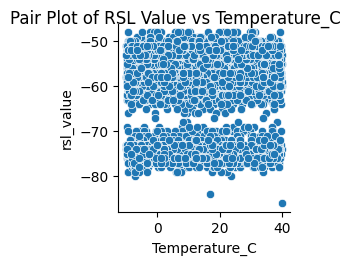

In [ ]:
# Pair plot for rsl_value vs temperature_c
sns.pairplot(merged_df[merged_df['frequency']==64800], y_vars=['rsl_value'], x_vars=['Temperature_C'], kind='scatter')
plt.suptitle('Pair Plot of RSL Value vs Temperature_C', y=1.02)
plt.show()

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154493 entries, 0 to 154492
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Datetime        154493 non-null  datetime64[ns]
 1   sublink_id      154493 non-null  int64         
 2   rsl_value       154493 non-null  float64       
 3   frequency       154493 non-null  int64         
 4   length          154493 non-null  float64       
 5   Temperature_C   154493 non-null  float64       
 6   Wind_Speed_kmh  154493 non-null  float64       
 7   Humidity_pct    154493 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 9.4 MB


In [ ]:
merged_df.describe()

,Datetime,sublink_id,rsl_value,frequency,length,Temperature_C,Wind_Speed_kmh,Humidity_pct
count,154493,154493.000000,154493.000000,154493.000000,154493.000000,154493.000000,154493.000000,154493.000000
mean,2024-03-04 09:22:04.478649344,51.879554,-59.890662,30374.820574,1638.096184,14.404808,15.100591,60.776447
min,2023-10-29 00:51:00,1.000000,-86.000000,5270.000000,24.500000,-9.991065,0.000000,30.122458
25%,2024-01-29 22:29:00,27.000000,-65.000000,5560.000000,582.300000,2.438279,7.681392,46.556329
50%,2024-03-02 22:12:00,52.000000,-59.000000,5810.000000,1397.800000,13.664718,14.966575,61.131892
75%,2024-04-10 09:41:00,78.000000,-55.000000,64800.000000,2220.000000,26.002169,22.863123,74.890636
max,2024-05-12 06:25:00,103.000000,-29.000000,69120.000000,6936.500000,39.980993,29.994572,97.000000
std,NaN,29.782790,7.661912,28102.235378,1334.254747,14.032395,8.691299,17.077343


In [ ]:
merged_df.isna().sum()

,0
Datetime,0
sublink_id,0
rsl_value,0
frequency,0
length,0
Temperature_C,0
Wind_Speed_kmh,0
Humidity_pct,0


In [ ]:
merged_df[merged_df['Wind_Speed_kmh'].isna()].head()

,Datetime,sublink_id,rsl_value,frequency,length,Temperature_C,Wind_Speed_kmh,Humidity_pct


In [ ]:
merged_df.corr()

,Datetime,sublink_id,rsl_value,frequency,length,Temperature_C,Wind_Speed_kmh,Humidity_pct
Datetime,1.000000,0.061097,-0.039861,-0.082453,-0.016345,0.050446,0.062436,-0.090136
sublink_id,0.061097,1.000000,-0.275148,-0.592642,-0.052206,0.004343,0.014747,-0.018158
rsl_value,-0.039861,-0.275148,1.000000,0.236315,0.074406,-0.003492,-0.002753,0.006757
frequency,-0.082453,-0.592642,0.236315,1.000000,0.049016,-0.006113,-0.018277,0.021710
length,-0.016345,-0.052206,0.074406,0.049016,1.000000,-0.001353,-0.003241,0.004236
Temperature_C,0.050446,0.004343,-0.003492,-0.006113,-0.001353,1.000000,0.008952,0.022374
Wind_Speed_kmh,0.062436,0.014747,-0.002753,-0.018277,-0.003241,0.008952,1.000000,-0.012035
Humidity_pct,-0.090136,-0.018158,0.006757,0.021710,0.004236,0.022374,-0.012035,1.000000


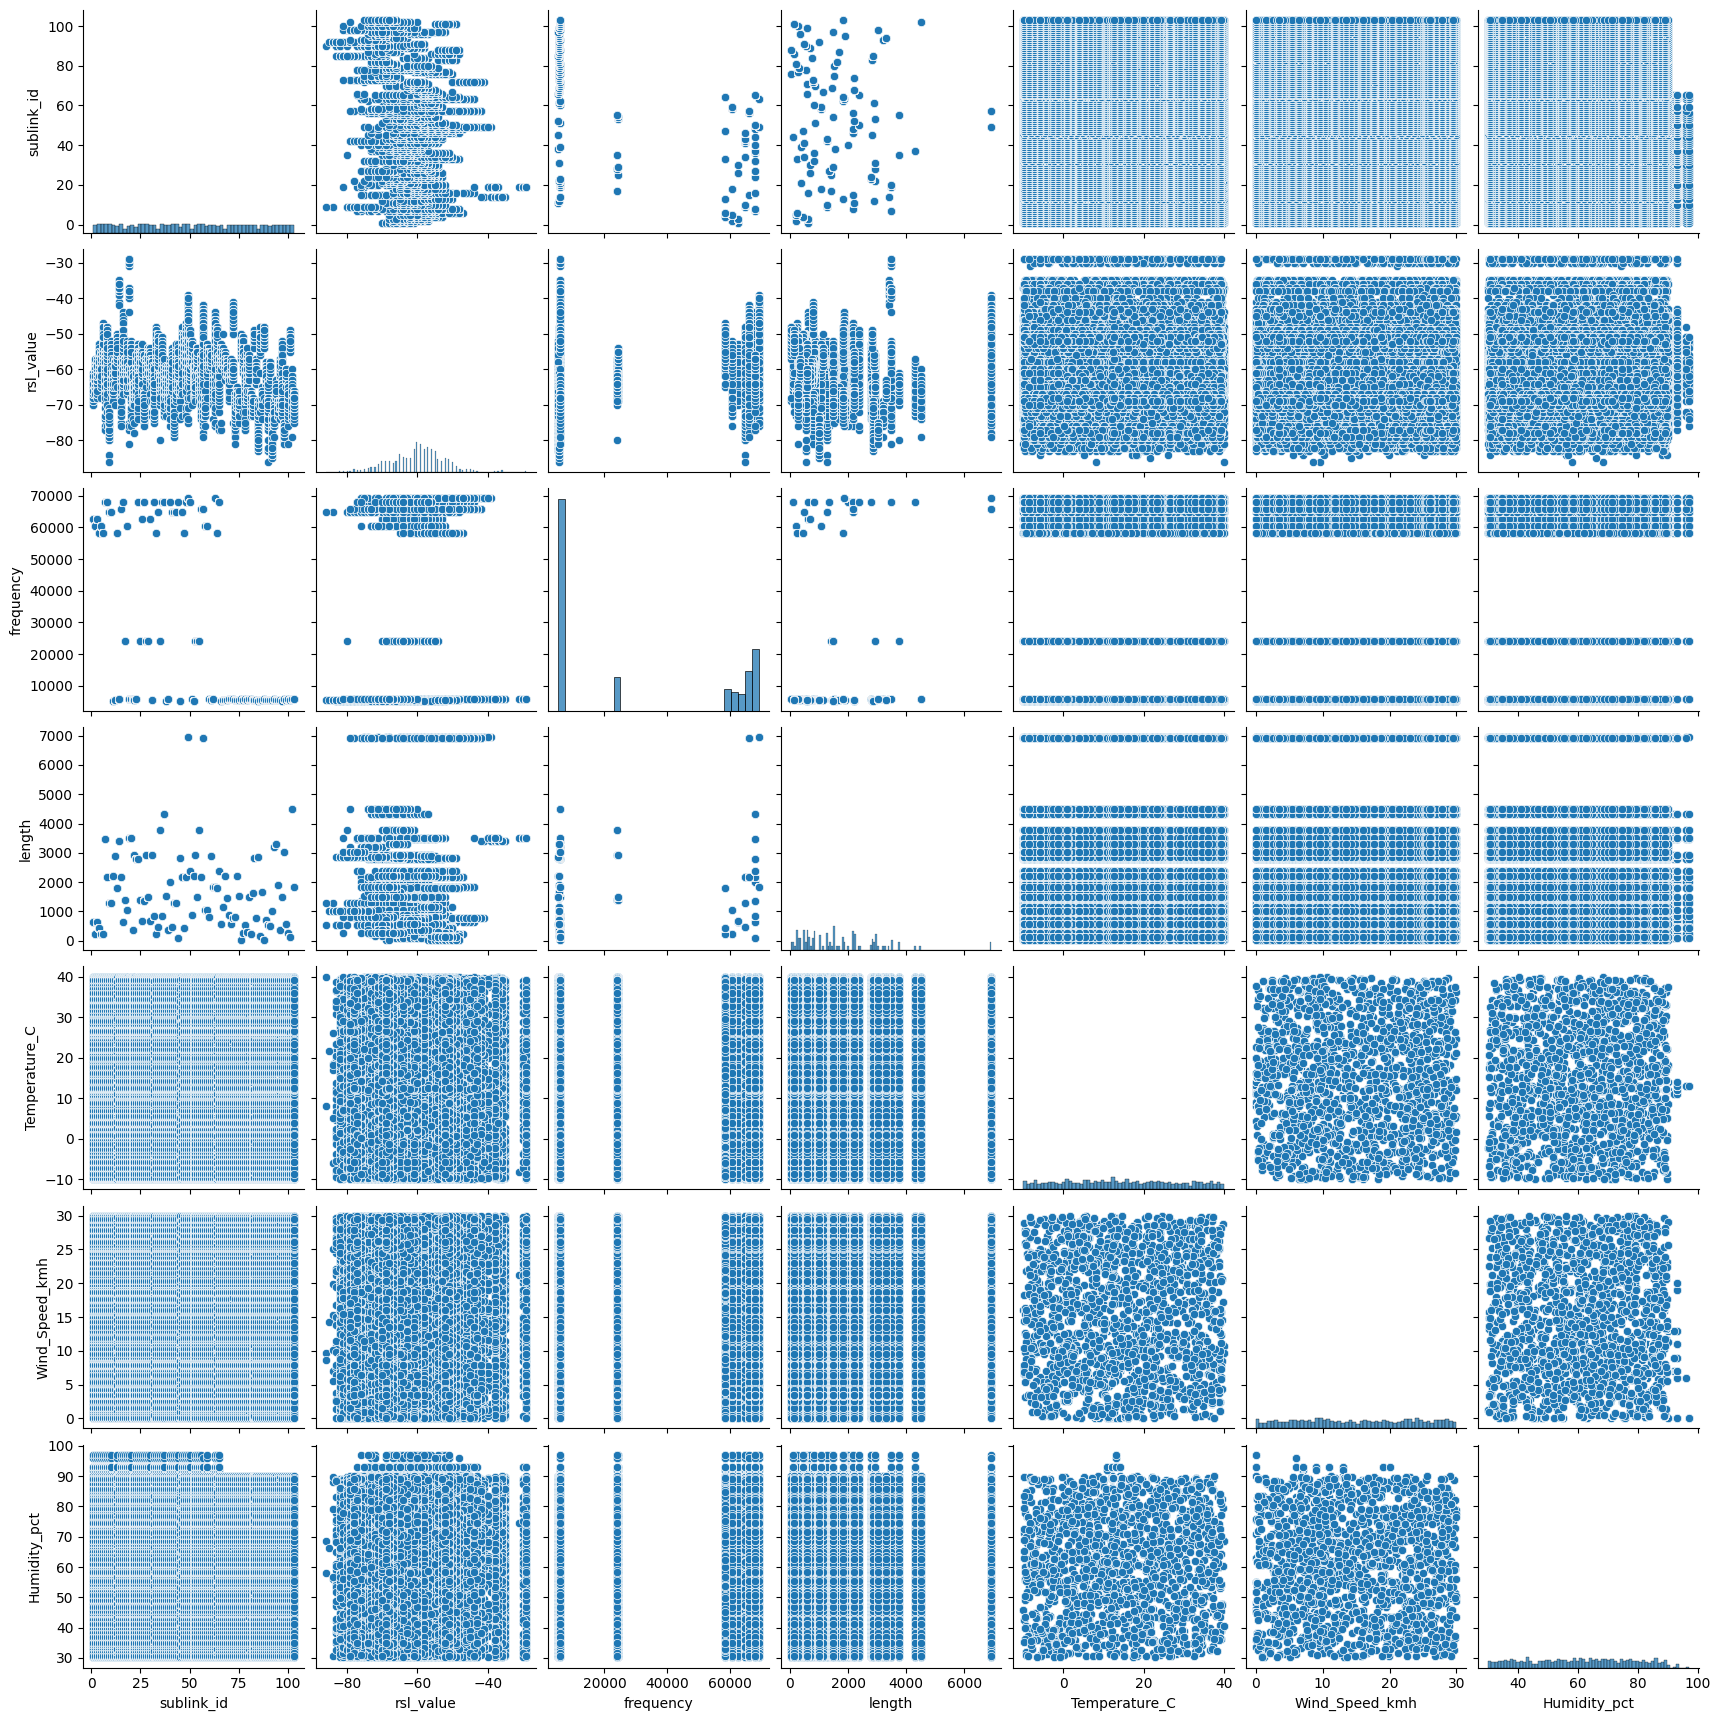

In [ ]:
#Pair Plot for numerical columns
sns.pairplot(merged_df, kind='scatter')
plt.show()

/tmp/ipython-input-2042180625.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merged_df['Temperature_C'])


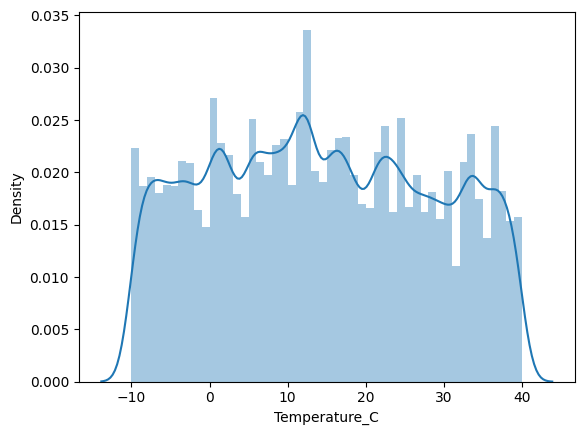

/tmp/ipython-input-2042180625.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merged_df['Wind_Speed_kmh'])


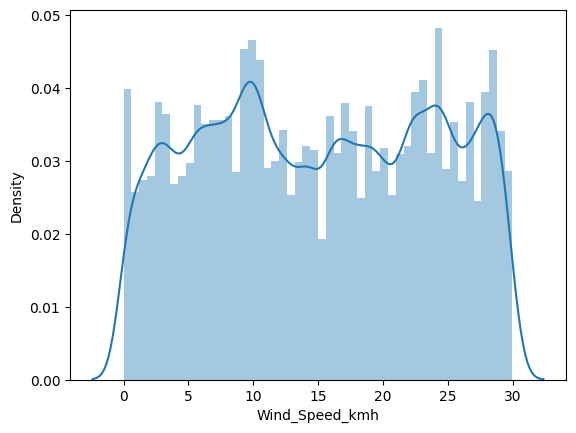

/tmp/ipython-input-2042180625.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merged_df['Humidity_pct'])


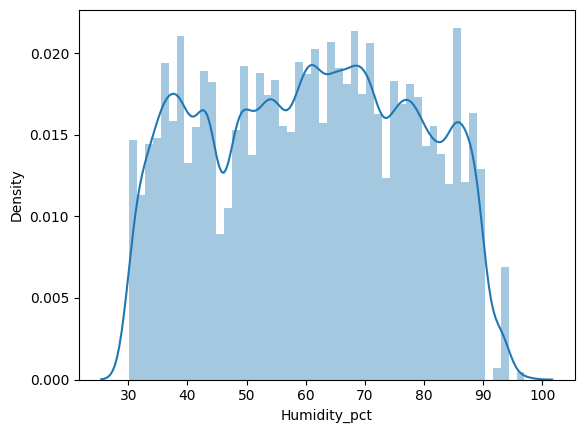

In [ ]:
#Distribution plot for Temperature, windspeed, humidity
sns.distplot(merged_df['Temperature_C'])
plt.show()

sns.distplot(merged_df['Wind_Speed_kmh'])
plt.show()

sns.distplot(merged_df['Humidity_pct'])
plt.show()

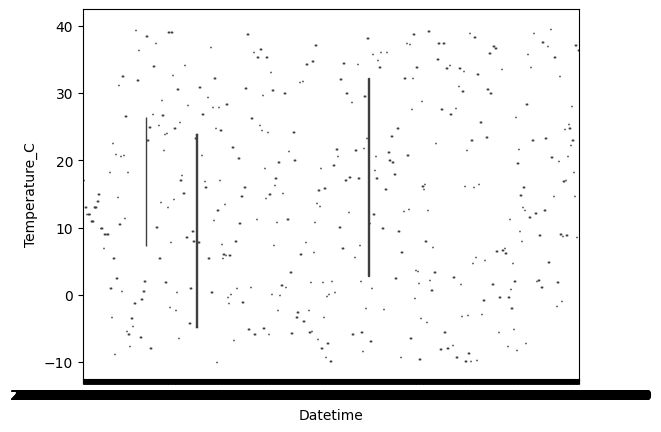

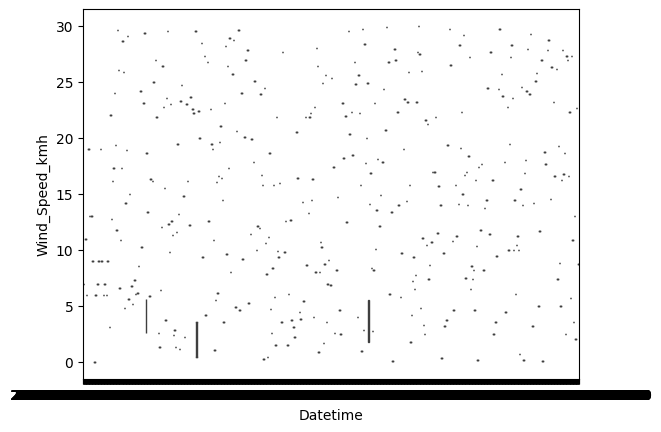

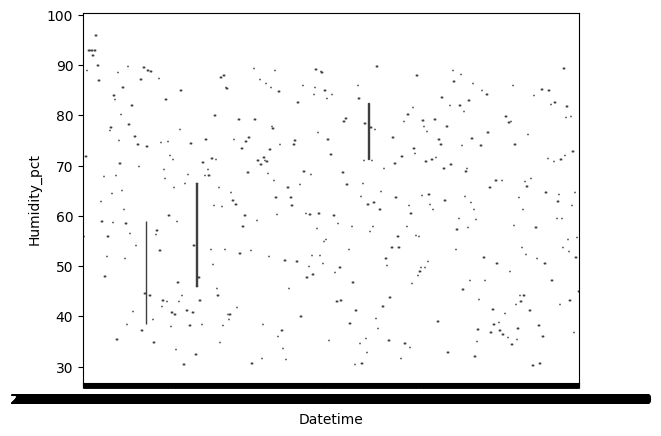

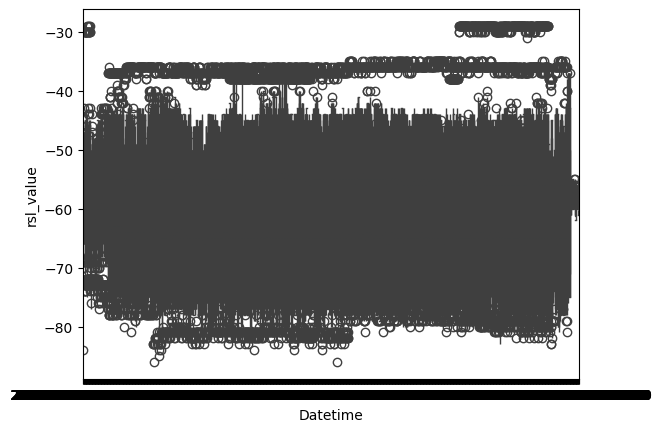

In [ ]:
#Box Plot for time, temperature, windspeed, humidity, rsl_value
sns.boxplot(x = 'Datetime', y = 'Temperature_C', data = merged_df)
plt.show()

sns.boxplot(x = 'Datetime', y = 'Wind_Speed_kmh', data = merged_df)
plt.show()

sns.boxplot(x = 'Datetime', y = 'Humidity_pct', data = merged_df)
plt.show()

sns.boxplot(x = 'Datetime', y = 'rsl_value', data = merged_df)
plt.show()

In [ ]:
#Pair Plot for numerical columns
'''
sns.pairplot(df[numeric_cols], kind='scatter')
plt.show()


# temperature
sns.distplot(BS_day['temp'])
plt.show()

plt.figure(figsize=(20, 20))
plt.subplot(3,3,1)
sns.boxplot(x = 'season', y = 'cnt', data = BS_day)
plt.subplot(3,3,2)
sns.boxplot(x = 'holiday', y = 'cnt', data = BS_day)
plt.subplot(3,3,3)
sns.boxplot(x = 'workingday', y = 'cnt', data = BS_day)
plt.subplot(3,3,4)
sns.boxplot(x = 'weathersit', y = 'cnt', data = BS_day)
plt.subplot(3,3,5)
sns.boxplot(x = 'mnth', y = 'cnt', data = BS_day)
plt.subplot(3,3,6)
sns.boxplot(x = 'weekday', y = 'cnt', data = BS_day)
plt.subplot(3,3,7)
sns.boxplot(x = 'yr', y = 'cnt', data = BS_day)
plt.show()
#plt.subplot(3,3,8)
#sns.boxplot(x = 'date', y = 'cnt', data = BS_day)
'''

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm # Used for F-statistic
import numpy as np # Import numpy for sqrt

# Sort the DataFrame by Datetime for time-series splitting
merged_df = merged_df.sort_values('Datetime')

# Define features (X) and target (y)
# Drop 'Datetime' as it's not a feature for the model, and 'rsl_value' is the target
X = merged_df.drop(columns=['Datetime', 'rsl_value'])
y = merged_df['rsl_value']

# Split data into training and testing sets (80:20 ratio)
# Shuffle is set to False for time-series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scale features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test) # Use the scaler fitted on training data

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)) # Use the scaler fitted on training data

# Instantiate and train Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

# Make predictions on the scaled test data
y_pred_scaled = model.predict(X_test_scaled)

# Inverse transform the scaled predictions to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Calculate RMSE by taking the square root of MSE
r_squared = r2_score(y_test, y_pred)

# Calculate F-statistic using statsmodels (requires adding a constant)
X_train_scaled_with_constant = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train_scaled, X_train_scaled_with_constant).fit()
f_statistic = ols_model.fvalue

print(f"RMSE: {rmse}")
print(f"R-squared: {r_squared}")
print(f"F-statistic: {f_statistic}")

RMSE: 7.744754728529586
R-squared: 0.0750981057876039
F-statistic: 2027.2104238326713


In [ ]:
ols_model.params


array([-3.63905683e-16, -1.80434772e-01,  1.41095944e-01,  6.83132755e-02,
       -2.64908402e-03,  3.27853902e-03,  4.65446525e-04])

In [ ]:
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     2027.
Date:                Thu, 30 Oct 2025   Prob (F-statistic):               0.00
Time:                        13:34:50   Log-Likelihood:            -1.6957e+05
No. Observations:              123594   AIC:                         3.392e+05
Df Residuals:                  123587   BIC:                         3.392e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.639e-16      0.003  -1.34e-13      1.000      -0.005       0.005
x1            -0.1804      0.003    -53.363      0.000      -0.187      -0.174
x2             0.1411      0.003     41.715      0.000       0.134       0.148
x3             0.0683      0.003     25.132      0.000       0.063       0.074
x4            -0.0026      0.003     -0.975      0.329      -0.008       0.003
x5             0.0033      0.003      1.207      0.227      -0.002       0.009
x6             0.0005      0.003      0.171      0.864      -0.005       0.006
==============================================================================
Omnibus:                      939.813   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1320.253
Skew:                           0.095   Prob(JB):                    2.05e-287
Kurtosis:                       3.469   Cond. No.                         2.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
from sklearn.model_selection import train_test_split

# We specify this so that the train and test data set always have the same rows, respectively
df_train, df_test = train_test_split(merged_df, train_size = 0.7, test_size = 0.3, random_state = 100)

In [ ]:
df_train.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'Temperature_C', 'Wind_Speed_kmh', 'Humidity_pct'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate Datetime column
df_train_datetime = df_train['Datetime']
df_train_numerical = df_train.drop(columns=['Datetime'])

# Identify numerical columns
numerical_cols = df_train_numerical.select_dtypes(include=['float64', 'int64']).columns

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical columns
df_train_scaled_numerical = scaler.fit_transform(df_train_numerical[numerical_cols])

# Create a new DataFrame with scaled numerical data and the Datetime column
df_train_scaled = pd.DataFrame(df_train_scaled_numerical, columns=numerical_cols)
df_train_scaled['Datetime'] = df_train_datetime.reset_index(drop=True)

display(df_train_scaled.head())

,sublink_id,rsl_value,frequency,length,Temperature_C,Wind_Speed_kmh,Humidity_pct,Datetime
0,-0.734323,0.116831,1.146309,-0.712857,0.777225,1.003896,1.000887,2024-01-05 12:17:00
1,-0.767918,0.508051,-0.221265,-0.120047,0.915160,0.143764,-1.579147,2024-03-20 17:52:00
2,0.609483,-0.404795,-0.876946,-0.581563,-0.113743,-0.299725,-1.718169,2024-01-02 13:19:00
3,-0.935894,0.247238,1.338423,0.864467,1.345405,-1.464328,-1.057737,2024-04-20 13:22:00
4,-1.372631,-0.404795,-0.893312,0.426897,0.303162,-0.921259,-0.862156,2024-04-15 20:51:00


In [ ]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
# Apply scaler() to all the columns except the 'yes-no' and 'dummy' variables
#var = ['temp', 'hum', 'windspeed','casual','registered','cnt']
#df_train[var] = scaler.fit_transform(df_train[var])

#from sklearn.preprocessing import scale
# storing column names in cols, since column names are (annoyingly) lost after
# scaling (the df is converted to a numpy array)
#train_cols = df_train.columns
#df_train = pd.DataFrame(scale(df_train))
#df_train.columns = train_cols
#df_train.columns

In [ ]:
df_y_train_scaled = df_train_scaled.pop('rsl_value')
df_train_scaled.head()

,sublink_id,frequency,length,Temperature_C,Wind_Speed_kmh,Humidity_pct,Datetime
0,-0.734323,1.146309,-0.712857,0.777225,1.003896,1.000887,2024-01-05 12:17:00
1,-0.767918,-0.221265,-0.120047,0.915160,0.143764,-1.579147,2024-03-20 17:52:00
2,0.609483,-0.876946,-0.581563,-0.113743,-0.299725,-1.718169,2024-01-02 13:19:00
3,-0.935894,1.338423,0.864467,1.345405,-1.464328,-1.057737,2024-04-20 13:22:00
4,-1.372631,-0.893312,0.426897,0.303162,-0.921259,-0.862156,2024-04-15 20:51:00


In [ ]:
df_y_test = df_test.pop('rsl_value')
df_test.head()

,Datetime,sublink_id,frequency,length,Temperature_C,Wind_Speed_kmh,Humidity_pct
42980,2024-04-10 06:41:00,29,24200,1480.4,33.513628,26.649208,32.999792
25478,2024-03-12 01:56:00,17,24100,1400.6,23.606356,19.637985,85.968243
61605,2024-04-21 01:15:00,41,64800,482.8,7.540981,29.625336,58.980041
28102,2024-02-12 03:16:00,19,5760,3489.4,25.043673,1.682062,88.122108
112253,2024-04-08 23:38:00,75,5560,1530.5,39.172008,7.362210,64.333467


In [ ]:
print("df_train_scaled", df_train_scaled.shape)
print("df_test", df_test.shape)
print("df_y_train_scaled", df_y_train_scaled.shape)
print("df_y_test", df_y_test.shape)

df_train_scaled (108145, 7)
df_test (46348, 7)
df_y_train_scaled (108145,)
df_y_test (46348,)


In [ ]:
#Linear Regression SM Sample
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# Drop the Datetime column before adding a constant and fitting the OLS model
df_train_scaled_numerical_only = df_train_scaled.drop(columns=['Datetime'])

X_train_lm = sm.add_constant(df_train_scaled_numerical_only)

lr = sm.OLS(df_y_train_scaled, X_train_lm).fit()

lr.params

# getting the model summary
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              rsl_value   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     1744.
Date:                Thu, 30 Oct 2025   Prob (F-statistic):               0.00
Time:                        12:29:36   Log-Likelihood:            -1.4846e+05
No. Observations:              108145   AIC:                         2.969e+05
Df Residuals:                  108138   BIC:                         2.970e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           4.582e-17      0.003   1.58e-14      1.000      -0.006       0.006
sublink_id        -0.2121      0.004    -58.781      0.000      -0.219      -0.205
frequency          0.1069      0.004     29.634      0.000       0.100       0.114
length             0.0558      0.003     19.178      0.000       0.050       0.061
Temperature_C     -0.0024      0.003     -0.830      0.407      -0.008       0.003
Wind_Speed_kmh     0.0017      0.003      0.578      0.563      -0.004       0.007
Humidity_pct       0.0029      0.003      1.006      0.314      -0.003       0.009
==============================================================================
Omnibus:                     2171.264   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3360.545
Skew:                           0.210   Prob(JB):                         0.00
Kurtosis:                       3.754   Cond. No.                         1.99
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
#Prediction
# Making predictions using the model
# Drop the Datetime column from df_test before prediction
df_test_numerical_only = df_test.drop(columns=['Datetime'])
# Add a constant to the test data
X_test_lm = sm.add_constant(df_test_numerical_only)
y_pred = lr.predict(X_test_lm)

#Step_7: Calculating Error Terms
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(df_y_test, y_pred)
r_squared = r2_score(df_y_test, y_pred)

print('Mean_Squared_Error :' ,mse)
print('r_square_value :',r_squared)


#Checking for P-value Using STATSMODELS
import statsmodels.api as sm
X_train_sm = df_train_scaled_numerical_only
#Unlike SKLearn, statsmodels don't automatically fit a constant,
#so you need to use the method sm.add_constant(X) in order to add a constant.
X_train_sm = sm.add_constant(X_train_sm)
# create a fitted model in one line
lm_1 = sm.OLS(df_y_train_scaled,X_train_sm).fit()

# print the coefficients
lm_1.params

print(lm_1.summary())

#Identify variables with High P-value eliminate them and create lm for prediction (lm.fit and lm.predict)

Mean_Squared_Error : 20460507.98573103
r_square_value : -349907.5384018196
                            OLS Regression Results                            
Dep. Variable:              rsl_value   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     1744.
Date:                Thu, 30 Oct 2025   Prob (F-statistic):               0.00
Time:                        13:01:21   Log-Likelihood:            -1.4846e+05
No. Observations:              108145   AIC:                         2.969e+05
Df Residuals:                  108138   BIC:                         2.970e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

In [ ]:
#Model Building using RFE
# Import RFE
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# RFE with a reasonable number of features (e.g., half of the original features)
lm = LinearRegression()
rfe1 = RFE(lm, n_features_to_select=3) # Selecting 3 features initially

# Fit RFE on the time-series training data
rfe1.fit(X_train, y_train)

# Print the boolean results
print("Selected Features by RFE:")
print(rfe1.support_)
print("Feature Ranking by RFE:")
print(rfe1.ranking_)

# Subset the features selected by rfe1
col1 = X_train.columns[rfe1.support_]

# Subsetting training data for selected columns
X_train_rfe1 = X_train[col1]

# Add a constant to the model
X_train_rfe1 = sm.add_constant(X_train_rfe1)
print("\nTraining data with selected features and constant:")
display(X_train_rfe1.head())

# Fitting the OLS model with selected variables
lm1 = sm.OLS(y_train, X_train_rfe1).fit()
print("\nOLS Model Summary:")
print(lm1.summary())

# Check for the VIF values of the feature variables.
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe that will contain the names of all the feature variables and their respective VIFs except for the constant
vif = pd.DataFrame()
vif['Features'] = X_train_rfe1.columns.drop('const')
vif['VIF'] = [variance_inflation_factor(X_train_rfe1[vif['Features']].values, i) for i in range(vif['Features'].shape[0])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
print("\nVIFs for the selected features:")
display(vif)

Selected Features by RFE:
[ True False False  True  True False]
Feature Ranking by RFE:
[1 4 3 1 1 2]

Training data with selected features and constant:


,const,sublink_id,Temperature_C,Wind_Speed_kmh
0,1.0,1,17.0,7.0
46495,1.0,32,17.0,7.0
78223,1.0,53,17.0,7.0
43386,1.0,30,17.0,7.0
79837,1.0,54,17.0,7.0



OLS Model Summary:
                            OLS Regression Results                            
Dep. Variable:              rsl_value   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     3182.
Date:                Thu, 30 Oct 2025   Prob (F-statistic):               0.00
Time:                        13:37:38   Log-Likelihood:            -4.2079e+05
No. Observations:              123594   AIC:                         8.416e+05
Df Residuals:                  123590   BIC:                         8.416e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -56.299

,Features,VIF
0,sublink_id,2.55
2,Wind_Speed_kmh,2.52
1,Temperature_C,1.79


### OLS Model Summary Analysis:

*R-squared* (0.072): This indicates that approximately 7.2% of the variance in your target variable (rsl_value) is explained by the features selected by RFE (sublink_id, Temperature_C, and Wind_Speed_kmh). This is a very low R-squared value, suggesting that these three features alone do not explain much of the variability in the rsl_value.

- *Adj. R-squared* (0.072): The adjusted R-squared is very close to the R-squared, which is expected when you have a relatively small number of predictors. It also confirms that the model's explanatory power is quite low.

- *F-statistic* (3182.) and *Prob (F-statistic)* (0.00): The F-statistic tests the overall significance of the regression model. A high F-statistic and a p-value (Prob (F-statistic)) close to 0 (like 0.00) indicate that the model is statistically significant, meaning that at least one of the predictors is related to the target variable. So, while the model doesn't explain much variance, it is statistically significant.

#### Coefficients (coef), Standard Errors (std err), t-statistic, and P>|t|:

- *sublink_id*: Has a statistically significant negative coefficient (-0.0681) with a p-value of 0.000. This suggests that as sublink_id increases, the rsl_value tends to decrease, holding other variables constant.

- *Temperature_C*: Has a very small negative coefficient (-0.0018) and a p-value of 0.223, which is greater than the conventional significance level of 0.05. This indicates that Temperature_C is not statistically significant in this model, meaning there's not enough evidence to conclude it has a linear relationship with rsl_value when considering the other variables.

- *Wind_Speed_kmh*: Has a very small positive coefficient (0.0013) and a p-value of 0.587, also greater than 0.05. Similar to Temperature_C, Wind_Speed_kmh is not statistically significant in this model.
VIFs Analysis:

VIFs: Variance Inflation Factor (VIF) measures how much the variance of the estimated regression coefficients is increased due to collinearity. A VIF value greater than 5 or 10 is generally considered an indication of significant multicollinearity.
Your VIF values are:
sublink_id: 2.55
Wind_Speed_kmh: 2.52
Temperature_C: 1.79
All these VIF values are well below the common thresholds (5 or 10). This indicates that there is no significant multicollinearity among the selected features (sublink_id, Temperature_C, and Wind_Speed_kmh).
Conclusion from Analysis:

The OLS summary and VIFs suggest that among the features selected by RFE (set to 3), only sublink_id is a statistically significant predictor of rsl_value. Temperature_C and Wind_Speed_kmh do not appear to be significant in this model. The overall model explains a very small portion of the variance in rsl_value.

This indicates that either the relationship between these features and rsl_value is not linear, or there are other important features not included in this set of 3, or a linear model is not the best fit for this data.

Would you like to try RFE with a different number of features, or perhaps explore other modeling techniques?

In [ ]:
#RFE2:
# Import RFE
from sklearn.feature_selection import RFE

# RFE with 7 features
lm = LinearRegression()
rfe2 = RFE(lm, 7)

# Fit with 7 features
rfe2.fit(X_train, y_train)

# Print the boolean results
print(rfe2.support_)
print(rfe2.ranking_)

# Import statsmodels
import statsmodels.api as sm

# Subset the features selected by rfe1
col1 = X_train.columns[rfe2.support_]

# Subsetting training data for 7 selected columns
X_train_rfe2 = X_train[col1]

# Add a constant to the model
X_train_rfe2 = sm.add_constant(X_train_rfe2)
X_train_rfe2.head()

# Fitting the model with 7 variables
lm2 = sm.OLS(y_train, X_train_rfe2).fit()
print(lm2.summary())

#Now let's check the VIF for these selected features and decide further.
b=X_train_rfe2.drop('const',axis=1)
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs except for the constant
vif = pd.DataFrame()
vif['Features'] = b.columns
vif['VIF'] = [variance_inflation_factor(b.values, i) for i in range(b.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

#From the model summary above, all the variables have p-value < 0.05 and from the p-value perspective, all variables seem significant. But notice that there are a few variables which have VIF > 5. We need to deal with these variables carefully.
#So let's try removing 'hum' first having the maximum VIF and then check for it again. Dropping this variable may result in a change in other VIFs which are high.

# Let's drop the 'hum' column
X_train_rfe2.drop("hum",axis=1,inplace=True)
X_train_rfe2

X_train_rfe2 = sm.add_constant(X_train_rfe2)

# Now that we have removed one variable, let's fit the model with 6 variables
lm3 = sm.OLS(y_train, X_train_rfe2).fit()
print(lm3.summary())

#The model seems to be doing a good job. Let's also quickly take a look at the VIF values.
c=X_train_rfe2.drop('const',axis=1)
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs except for the constant
vif = pd.DataFrame()
vif['Features'] = c.columns
vif['VIF'] = [variance_inflation_factor(c.values, i) for i in range(c.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

#Residual Analysis
y_train_cnt = lm3.predict(X_train_rfe2)
# Plot the histogram of the error terms
fig = plt.figure()
sns.distplot((y_train - y_train_cnt), bins = 20)
# Plot heading
fig.suptitle('Error Terms', fontsize = 20)
# Give the X-label
plt.xlabel('Errors', fontsize = 18)

#Make Prediction
X_train_rfe2

# let's recall the set of variables which are to be scaled
var

df_test[var] = scaler.transform(df_test[var])
# Split the 'df_test' set into X and y after scaling
y_test = df_test.pop('cnt')
X_test = df_test.drop(["casual","registered"],axis=1)

X_test.head()

# Let's check the list 'col2' which had the 6 variables RFE had selected
col2=c.columns
col2

# Let's subset these columns and create a new dataframe 'X_test_rfe1'
X_test_rfe2 = X_test[col2]

# Add a constant to the test set created
X_test_rfe2 = sm.add_constant(X_test_rfe2)
X_test_rfe2.info()

# Making predictions
y_pred = lm3.predict(X_test_rfe2)
# Plotting y_test and y_pred to understand the spread

fig = plt.figure()
plt.scatter(y_test, y_pred)
fig.suptitle('y_test vs y_pred', fontsize = 20)              # Plot heading
plt.xlabel('y_test', fontsize = 18)                          # X-label
plt.ylabel('y_pred', fontsize = 16)

#From the above plot, it's evident that the model is doing well on the test set as well. Let's also check the R-squared and more importantly, the adjusted R-squared value for the test set.

# r2_score for 6 variables
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

#Thus, for the model with 6 variables, the r-squared on training and test data is about 79.3% and 78.02% respectively. The adjusted r-squared on the train set is about is about 79.1%.
# Figure size
plt.figure(figsize=(8,5))

#Check the correlations between the final predictor variables
# Heatmap
sns.heatmap(BS_day[col2].corr(), cmap="YlGnBu", annot=True)
plt.show()

In [ ]:
test_cols = df_test.columns
df_test = pd.DataFrame(scale(df_test))
df_test.columns = test_cols
df_test.columns

In [ ]:
y_train = df_train.pop('SalePrice')
X_train = df_train

y_test = df_test.pop('SalePrice')
X_test = df_test

In [ ]:
#Model Building using RFE
# Importing RFE and LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [ ]:
# Running RFE with the output number of the variable equal to 100 and remove 10 features at each step
lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(lm, n_features_to_select=100, step = 10)             # running RFE
rfe = rfe.fit(X_train, y_train)

In [ ]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

In [ ]:
rfe_col = X_train.columns[rfe.support_]
rfe_col

In [ ]:
len(rfe_col), len(list(X_train.columns))

In [ ]:
X_train.columns[~rfe.support_]

In [ ]:
# Print the coefficients and intercept
print("Intercept ", lm.intercept_)
print("Coefficients for ",len(lm.coef_), " features = ", lm.coef_)

In [ ]:
#Get R2-Score, Residual Sum of Square and Root Mean Square on the target variable
def r2_score_rss_mse(dataset_type="Train", y_train=None, y_pred_train=None):
    metric = []
    r2_train_lr = r2_score(y_train, y_pred_train)
    print(dataset_type, " DataSet: R2 Score = ", r2_train_lr)
    metric.append(r2_train_lr)

    rss1_lr = np.sum(np.square(y_train - y_pred_train))
    print(dataset_type, " DataSet: Residual-Sum of Square = ", rss1_lr)
    metric.append(rss1_lr)

    mse_train_lr = mean_squared_error(y_train, y_pred_train)
    print(dataset_type, " DataSet: Mean Square Error = ", mse_train_lr)
    metric.append(mse_train_lr**0.5)
    return metric

In [ ]:
y_pred_train = lm.predict(X_train)
metric = r2_score_rss_mse("Train", y_train, y_pred_train)

In [ ]:
y_pred_test = lm.predict(X_test)
metric += r2_score_rss_mse("Test", y_test, y_pred_test)

In [ ]:
# printing the overall accuracy
from sklearn import metrics
metrics.accuracy_score(y_test, y_pred_class)

# confusion matrix
metrics.confusion_matrix(y_test, y_pred_class)
# help(metrics.confusion_matrix)

confusion = metrics.confusion_matrix(y_test, y_pred_class)
print(confusion)
TN = confusion[0, 0]
FP = confusion[0, 1]
FN = confusion[1, 0]
TP = confusion[1, 1]

sensitivity = TP / float(FN + TP)
print("sensitivity",sensitivity)

specificity = TN / float(TN + FP)
print("specificity",specificity)

precision = TP / float(TP + FP)
print("precision",precision)
print(metrics.precision_score(y_test, y_pred_class))

print("precision",precision)
print("PRECISION SCORE :",metrics.precision_score(y_test, y_pred_class))
print("RECALL SCORE :", metrics.recall_score(y_test, y_pred_class))
print("F1 SCORE :",metrics.f1_score(y_test, y_pred_class))

In [ ]:
# creating an ROC curve
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_proba[:,1])
roc_auc = auc(false_positive_rate, true_positive_rate)

# area under the curve
print (roc_auc)

# matrix of thresholds, tpr, fpr
pd.DataFrame({'Threshold': thresholds,
              'TPR': true_positive_rate,
              'FPR':false_positive_rate
             })

# plotting the ROC curve
%matplotlib inline
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC')
plt.plot(false_positive_rate, true_positive_rate)

In [ ]:
Regression and Lasso Modelling
Let's now try predicting car prices, a dataset used in simple linear regression, to perform ridge and lasso regression.
Ridge Regression

from sklearn import linear_model, metrics
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
Ridge Model
# list of alphas to tune - if value too high it will lead to underfitting, if it is too low,
# it will not handle the overfitting
params = {'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1,
 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100, 500, 1000 ]}

ridge = Ridge()

# cross validation
folds = 5
model_cv = GridSearchCV(estimator = ridge,
                        param_grid = params,
                        scoring= 'neg_mean_absolute_error',
                        cv = folds,
                        return_train_score=True,
                        verbose = 1)
model_cv.fit(X_train, y_train)
#https://scikit-learn.org/stable/modules/model_evaluation.html

In [ ]:
print(model_cv.best_params_)

In [ ]:
#Fitting Ridge model for alpha = 10 and printing coefficients which have been penalised
alpha = 100
ridge = Ridge(alpha=alpha)

ridge.fit(X_train, y_train)
print("Train dataset: Ridge Coefficient = ", ridge.coef_)

In [ ]:
Print Scores from Ridge Model on Train and Test target
y_pred_train = ridge.predict(X_train)
metric1 = r2_score_rss_mse("Train", y_train, y_pred_train)

In [ ]:
y_pred_test = ridge.predict(X_test)
metric1 += r2_score_rss_mse("Test", y_test, y_pred_test)

In [ ]:
Lasso
lasso = Lasso()

# cross validation
model_cv = GridSearchCV(estimator = lasso,
                        param_grid = params,
                        scoring= 'neg_mean_absolute_error',
                        cv = folds,
                        return_train_score=True,
                        verbose = 1)

model_cv.fit(X_train, y_train)

In [ ]:
print("Lasso model_cv.best_params_ ", model_cv.best_params_)

In [ ]:
#Fitting Lasso model for alpha = 0.01 and printing coefficients which have been penalised

alpha = 0.01

lasso = Lasso(alpha=alpha)

lasso.fit(X_train, y_train)

In [ ]:
print("Lasso coefficeint = ", lasso.coef_)

In [ ]:
Print Scores from Lasso Model on Train and Test target
y_pred_train = lasso.predict(X_train)
metric2 = r2_score_rss_mse("Train", y_train, y_pred_train)

In [ ]:
y_pred_test = lasso.predict(X_test)
metric2 += r2_score_rss_mse("Test", y_test, y_pred_test)

In [ ]:
Table:
# Creating a table which contain all the metrics

lr_table = {'Metric': ['R2 Score (Train)','RSS (Train)', 'MSE (Train)', 'R2 Score (Test)', 'RSS (Test)', 'MSE (Test)'],
        'Linear Regression': metric
        }

lr_metric = pd.DataFrame(lr_table ,columns = ['Metric', 'Linear Regression'] )

rg_metric = pd.Series(metric1, name = 'Ridge Regression (Alpha = 100)')
ls_metric = pd.Series(metric2, name = 'Lasso Regression (Alpha = 0.01)')

final_metric = pd.concat([lr_metric, rg_metric, ls_metric], axis = 1)
final_metric

In [ ]:
Log observation of the changes in the coefficients after regularization
betas = pd.DataFrame(index=df_train.columns)
betas.rows = df_train.columns
betas['Linear'] = lm.coef_
betas['Ridge'] = ridge.coef_
betas['Lasso'] = lasso.coef_
pd.set_option('display.max_rows', None)
betas.head(210)

In [ ]:
#data['res'] =
def plot_scatter(Title="Scatter Plot", y_train=None, y_pred_train=None):
    plt.scatter( y_pred_train , y_train - y_pred_train)
    plt.axhline(y=0, color='r', linestyle=':')
    plt.xlabel("Predictions")
    plt.ylabel("Residual")
    plt.show()

In [ ]:
# Distribution of errors
def dist_plot(Title="Normality of error terms/residuals", y_train=None, y_pred_train=None):
    p = sns.distplot(y_train - y_pred_train, kde=True)
    p = plt.title('Normality of error terms/residuals')
    plt.xlabel("Residuals")
    plt.show()

In [ ]:
plot_scatter("Train residual Scatter plot", y_train, y_pred_train)

In [ ]:
dist_plot("Target variable Error term Distribution plot", y_train, y_pred_train)

In [ ]:
plot_scatter("Test residual Scatter plot", y_test, y_pred_test)

In [ ]:
dist_plot("Target variable Error term Distribution plot", y_test, y_pred_test)

In [ ]:
Top Features
get_top_feature = lambda df, col, count: df[col].sort_values(ascending=False).head(count)
get_top_feature(betas,'Linear',10)

In [ ]:
get_top_feature(betas, 'Ridge', 10)

In [ ]:
get_top_feature(betas, 'Lasso', 10)

In [ ]:
Double the value of alpha for Ridge and Lasso¶
Ridge Model (Double vale of Alpha)


In [ ]:
# list of alphas to tune - if value too high it will lead to underfitting, if it is too low,
# it will not handle the overfitting
params = {'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1,
 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100, 500, 1000 ]}

ridge = Ridge()

# cross validation
folds = 5
ridge_model_cv = GridSearchCV(estimator = ridge,
                        param_grid = params,
                        scoring= 'neg_mean_absolute_error',
                        cv = folds,
                        return_train_score=True,
                        verbose = 1)
ridge_model_cv.fit(X_train, y_train)
#https://scikit-learn.org/stable/modules/model_evaluation.html

In [ ]:
print(ridge_model_cv.best_params_)
#Fitting Ridge model for alpha = 100 and printing coefficients which have been penalised
alpha = 200  ## Double the value of best alpha value
ridge = Ridge(alpha=alpha)

ridge.fit(X_train, y_train)
print("Train dataset: Ridge Coefficient = ", ridge.coef_)

In [ ]:
Print Scores from Ridge Model on Train and Test target

y_pred_train = ridge.predict(X_train)
metric1 = r2_score_rss_mse("Train", y_train, y_pred_train)

y_pred_test = ridge.predict(X_test)
metric1 += r2_score_rss_mse("Test", y_test, y_pred_test)

In [ ]:
Lasso
lasso = Lasso()

# cross validation
lasso_model_cv = GridSearchCV(estimator = lasso,
                        param_grid = params,
                        scoring= 'neg_mean_absolute_error',
                        cv = folds,
                        return_train_score=True,
                        verbose = 1)

lasso_model_cv.fit(X_train, y_train)

In [ ]:
print("Lasso model_cv.best_params_ ", lasso_model_cv.best_params_)
#Fitting Lasso model for alpha = 0.01 and printing coefficients which have been penalised

alpha = 0.02

lasso = Lasso(alpha=alpha)

lasso.fit(X_train, y_train)
print("Lasso coefficeint = ", lasso.coef_)

In [ ]:
Print Scores from Lasso Model on Train and Test target

y_pred_train = lasso.predict(X_train)
metric2 = r2_score_rss_mse("Train", y_train, y_pred_train)

y_pred_test = lasso.predict(X_test)
metric2 += r2_score_rss_mse("Test", y_test, y_pred_test)

### Train-Test Split with 80:20 ratio

In [ ]:
from sklearn.model_selection import train_test_split

# Sort the DataFrame by Datetime for time-series splitting
merged_df = merged_df.sort_values('Datetime')

# Define features (X) and target (y)
# Drop 'Datetime' as it's not a feature for the model, and 'rsl_value' is the target
X = merged_df.drop(columns=['Datetime', 'rsl_value'])
y = merged_df['rsl_value']

# Split data into training and testing sets (80:20 ratio)
# Shuffle is set to False for time-series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (123594, 6)
Shape of X_test: (30899, 6)
Shape of y_train: (123594,)
Shape of y_test: (30899,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit and transform the training features
X_train_scaled = scaler_X.fit_transform(X_train)

# Reshape y_train for scaling and then fit and transform
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of y_train_scaled:", y_train_scaled.shape)

Shape of X_train_scaled: (123594, 6)
Shape of y_train_scaled: (123594, 1)


In [ ]:
X_train_scaled

array([[-1.70758914,  1.13205613, -0.76174539,  0.19369156, -0.91351273,
        -0.29011248],
       [-0.52945583,  1.32386706, -0.59898195,  0.19369156, -0.91351273,
        -0.29011248],
       [ 0.41305082,  0.9786074 ,  0.12898445,  0.19369156, -0.91351273,
        -0.29011248],
       ...,
       [-1.33731867, -0.89740999,  0.93551594,  0.85525985, -1.2617658 ,
         0.3930486 ],
       [ 0.11010226, -0.23690553,  1.60061524,  0.85525985, -1.2617658 ,
         0.3930486 ],
       [-0.02454155, -0.88799705, -0.57952846,  0.85525985, -1.2617658 ,
         0.3930486 ]])

In [ ]:
from sklearn.linear_model import LinearRegression

# Instantiate Linear Regression model
model = LinearRegression()

# Train the model using scaled training data
model.fit(X_train_scaled, y_train_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


# Task
Perform scaling, PrincipalComponentAnalysis, train -test split, perform multiple Linear Regression, save model and test F-score, accuracy, precision on the time-series data with time-serires identified by Datetime column and rsl_value is the target variable.

## Scaling

### Subtask:
Scale the features of the `merged_df` DataFrame.


**Reasoning**:
The subtask is to scale the numerical features of the merged_df DataFrame, excluding the 'Datetime' column. I will import the StandardScaler, identify the numerical columns, instantiate and fit the scaler, transform the data, and then update the DataFrame with the scaled values.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns excluding 'Datetime'
numerical_cols = merged_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical columns
merged_df[numerical_cols] = scaler.fit_transform(merged_df[numerical_cols])

display(merged_df.head())

,Datetime,sublink_id,rsl_value,frequency,length,Temperature_C,Wind_Speed_kmh,Humidity_pct
0,2023-10-29 00:51:00,-1.707984,-0.667051,1.147514,-0.760845,0.185089,-0.932038,-0.280320
1,2023-10-29 01:51:00,-1.707984,-0.667051,1.147514,-0.760845,0.185089,-0.932038,-0.280320
2,2023-10-29 02:51:00,-1.707984,-0.667051,1.147514,-0.760845,0.113803,-0.471806,-0.163236
3,2023-10-29 03:51:00,-1.707984,-0.667051,1.147514,-0.760845,0.113803,-0.701922,-0.514489
4,2023-10-29 04:51:00,-1.707984,-0.667051,1.147514,-0.760845,-0.171343,-1.047096,1.300318


In [ ]:
merged_df.describe()

,Datetime,sublink_id,rsl_value,frequency,length,Temperature_C,Wind_Speed_kmh,Humidity_pct
count,154592,1.545920e+05,1.545920e+05,1.545920e+05,1.545920e+05,1.545920e+05,1.544930e+05,1.545920e+05
mean,2024-03-04 07:26:05.656825344,-2.353278e-17,-2.676853e-16,-1.647294e-16,1.838498e-16,-1.351296e-17,-2.345587e-16,-6.502768e-16
min,2023-10-29 00:51:00,-1.707984e+00,-3.408203e+00,-8.938286e-01,-1.209391e+00,-1.739004e+00,-1.737443e+00,-1.795247e+00
25%,2024-01-29 22:29:00,-8.685362e-01,-6.670508e-01,-8.835098e-01,-7.913476e-01,-8.529621e-01,-8.536381e-01,-8.331732e-01
50%,2024-03-02 22:05:00,4.489377e-03,1.161356e-01,-8.746143e-01,-1.801710e-01,-5.297348e-02,-1.541962e-02,2.048137e-02
75%,2024-04-10 09:41:00,8.775149e-01,6.382598e-01,1.224372e+00,4.360268e-01,8.268199e-01,8.931411e-01,8.255781e-01
max,2024-05-12 06:25:00,1.716963e+00,4.032067e+00,1.378086e+00,3.970808e+00,1.823318e+00,1.713671e+00,2.119908e+00
std,NaN,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00


## Principal component analysis (pca)

### Subtask:
Apply PCA to the scaled features of the `merged_df` DataFrame.


**Reasoning**:
Apply PCA to the scaled features of the `merged_df` DataFrame.



In [ ]:
from sklearn.decomposition import PCA

# Select the columns from merged_df that were scaled (all columns except 'Datetime')
scaled_features = merged_df.drop(columns=['Datetime'])

# Instantiate a PCA object. Setting n_components to None to keep all components initially for analysis.
pca = PCA(n_components=None)

# Fit the PCA model to the selected scaled data
pca.fit(scaled_features)

# Transform the scaled data using the fitted PCA model
pca_transformed_data = pca.transform(scaled_features)

# Create a new DataFrame to store the PCA-transformed data, ensuring the 'Datetime' column is also included
pca_df = pd.DataFrame(pca_transformed_data, columns=[f'PC{i+1}' for i in range(pca_transformed_data.shape[1])])
pca_df['Datetime'] = merged_df['Datetime']

display(pca_df.head())

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

**Reasoning**:
The previous command failed because of missing values in the scaled features. I need to handle the missing values before applying PCA. I will impute the missing values with the mean of the column.



In [ ]:
from sklearn.impute import SimpleImputer

# Identify numerical columns excluding 'Datetime'
numerical_cols = merged_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Instantiate SimpleImputer with mean strategy
imputer = SimpleImputer(strategy='mean')

# Fit and transform the numerical columns
merged_df[numerical_cols] = imputer.fit_transform(merged_df[numerical_cols])

# Select the columns from merged_df that were scaled and imputed
scaled_features = merged_df.drop(columns=['Datetime'])

# Instantiate a PCA object. Setting n_components to None to keep all components initially for analysis.
pca = PCA(n_components=None)

# Fit the PCA model to the selected scaled data
pca.fit(scaled_features)

# Transform the scaled data using the fitted PCA model
pca_transformed_data = pca.transform(scaled_features)

# Create a new DataFrame to store the PCA-transformed data, ensuring the 'Datetime' column is also included
pca_df = pd.DataFrame(pca_transformed_data, columns=[f'PC{i+1}' for i in range(pca_transformed_data.shape[1])])
pca_df['Datetime'] = merged_df['Datetime']

display(pca_df.head())